# Test 19: Sparse Autoencoder на активациях LLM

**Вопрос:** Работает ли chaos activation на реальных активациях языковой модели?

**План:**
- Загрузить GPT-2 small через Hugging Face
- Прогнать текст (OpenWebText subset), извлечь активации из MLP слоя
- Обучить SAE: Chaos a=1 + TopK vs ReLU + TopK
- Измерить: MSE, dead latents, устойчивость к квантованию

**Почему это важно:**
- Anthropic и OpenAI используют SAE для interpretability LLM
- Проблема dead latents — основная в их работах
- Прямое сравнение на реальных данных, не синтетике

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import json
from datetime import datetime
import torch
from transformers import GPT2Model, GPT2Tokenizer
from datasets import load_dataset

print(f"TF version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU (TF): {tf.config.list_physical_devices('GPU')}")
print(f"GPU (PT): {torch.cuda.is_available()}")

TF version: 2.16.2
PyTorch version: 2.8.0
GPU (TF): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU (PT): False


In [10]:
# === Шаг 1: Извлечение активаций из GPT-2 ===

print("Загрузка GPT-2 small...")
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2Model.from_pretrained('gpt2')
model.eval()

# Размерность активаций GPT-2 small: 768
ACTIVATION_DIM = 768
TARGET_LAYER = 6  # Средний слой (из 12)

print(f"Model loaded. Hidden dim: {ACTIVATION_DIM}, Target layer: {TARGET_LAYER}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Загрузка GPT-2 small...


vocab.json:  11%|#1        | 115k/1.04M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Model loaded. Hidden dim: 768, Target layer: 6
Total parameters: 124,439,808


In [11]:
# === Загрузка текстов ===

print("Загрузка текстов...")
dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
texts = [t for t in dataset['text'] if len(t) > 100][:500]
print(f"Текстов для обработки: {len(texts)}")
print(f"Пример: {texts[0][:200]}...")

Загрузка текстов...


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Текстов для обработки: 500
Пример:  Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ p...


In [12]:
# === Извлечение активаций ===

print("Извлечение активаций...")
all_activations = []

tokenizer.pad_token = tokenizer.eos_token

with torch.no_grad():
    for i, text in enumerate(texts):
        inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
        outputs = model(**inputs, output_hidden_states=True)
        
        # Берём активации из target_layer
        hidden = outputs.hidden_states[TARGET_LAYER]  # [1, seq_len, 768]
        # Берём все токены
        acts = hidden.squeeze(0).numpy()  # [seq_len, 768]
        all_activations.append(acts)
        
        if (i + 1) % 100 == 0:
            print(f"  Обработано {i+1}/{len(texts)} текстов")

# Объединяем все активации
activations = np.concatenate(all_activations, axis=0).astype('float32')
print(f"\nИтого активаций: {activations.shape}")
print(f"Диапазон: [{activations.min():.3f}, {activations.max():.3f}]")
print(f"Среднее: {activations.mean():.3f}, std: {activations.std():.3f}")

# Освобождаем память от GPT-2
del model, tokenizer
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("GPT-2 удалён из памяти.")

Извлечение активаций...
  Обработано 100/500 текстов
  Обработано 200/500 текстов
  Обработано 300/500 текстов
  Обработано 400/500 текстов
  Обработано 500/500 текстов

Итого активаций: (54573, 768)
Диапазон: [-72.623, 2938.315]
Среднее: 0.033, std: 10.727
GPT-2 удалён из памяти.


Train: (43658, 768), Test: (10915, 768)
Norm range: [-10.99, 10.76]


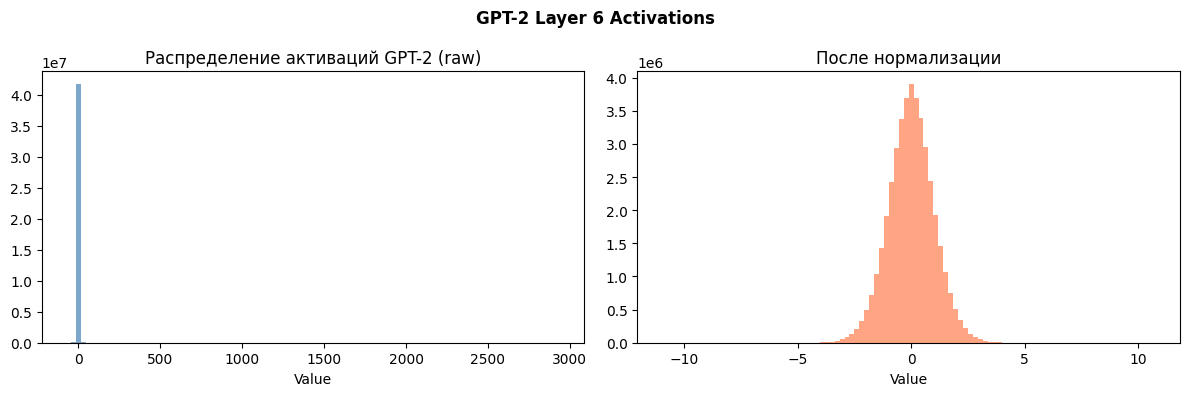

In [13]:
# === Нормализация активаций ===

# Стандартизация (mean=0, std=1) — стандарт для SAE на LLM
act_mean = activations.mean(axis=0, keepdims=True)
act_std = activations.std(axis=0, keepdims=True) + 1e-8
activations_norm = ((activations - act_mean) / act_std).astype('float32')

# Train/test split
np.random.seed(42)
indices = np.random.permutation(len(activations_norm))
split = int(len(indices) * 0.8)
x_train = activations_norm[indices[:split]]
x_test = activations_norm[indices[split:]]

print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Norm range: [{activations_norm.min():.2f}, {activations_norm.max():.2f}]")

# Визуализация распределения активаций
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(activations.flatten(), bins=100, alpha=0.7, color='steelblue')
axes[0].set_title('Распределение активаций GPT-2 (raw)')
axes[0].set_xlabel('Value')
axes[1].hist(activations_norm.flatten(), bins=100, alpha=0.7, color='coral')
axes[1].set_title('После нормализации')
axes[1].set_xlabel('Value')
plt.suptitle(f'GPT-2 Layer {TARGET_LAYER} Activations', fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# === SAE компоненты ===

class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def chaos_activation(x):
    return tf.sin(1.0 * x) + 0.5 * tf.tanh(4.0 * x)


def build_sae(input_dim, latent_dim, k_active, use_chaos=True):
    """Sparse Autoencoder для LLM активаций"""
    input_act = keras.Input(shape=(input_dim,))
    
    if use_chaos:
        x = layers.Dense(latent_dim, name='latent_pre')(input_act)
        x = layers.Activation(chaos_activation)(x)
    else:
        x = layers.Dense(latent_dim, activation='relu', name='latent_pre')(input_act)
    
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_act, latent, name='encoder')
    
    # Декодер — один слой (стандарт для SAE на LLM)
    decoded = layers.Dense(input_dim, name='decoder')(latent)
    
    autoencoder = keras.Model(input_act, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


print("SAE components ready.")

SAE components ready.


In [15]:
# === Эксперимент ===

NUM_RUNS = 5
EPOCHS = 10
BATCH_SIZE = 256
INPUT_DIM = ACTIVATION_DIM  # 768
LATENT_DIM = INPUT_DIM * 4  # 3072 — стандартный overcomplete factor 4x
K_ACTIVE = LATENT_DIM // 10  # ~10% спarsity

print(f"Config: input={INPUT_DIM}, latent={LATENT_DIM}, K={K_ACTIVE}")
print(f"Overcomplete ratio: {LATENT_DIM/INPUT_DIM:.0f}x")
print(f"Sparsity: {(1 - K_ACTIVE/LATENT_DIM)*100:.0f}%")

methods = {
    'Chaos_a1': True,
    'TopK_ReLU': False,
}

results = {}

for method_name, use_chaos in methods.items():
    print(f"\n{'='*60}")
    print(f"  {method_name}")
    print(f"{'='*60}")
    
    runs = []
    for run in range(NUM_RUNS):
        np.random.seed(run)
        tf.random.set_seed(run)
        
        ae, enc = build_sae(INPUT_DIM, LATENT_DIM, K_ACTIVE, use_chaos=use_chaos)
        if run == 0:
            print(f"  Parameters: {ae.count_params():,}")
        
        history = ae.fit(
            x_train, x_train,
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            validation_data=(x_test, x_test),
            verbose=0
        )
        
        # Анализ латентов
        latents = enc.predict(x_test, verbose=0)
        dead = int(np.sum(np.all(np.abs(latents) < 1e-6, axis=0)))
        val_loss = float(history.history['val_loss'][-1])
        
        # Квантование 4 бит
        q_latents = np.zeros_like(latents)
        for i in range(latents.shape[0]):
            nz = np.where(np.abs(latents[i]) > 1e-10)[0]
            if len(nz) == 0:
                continue
            vals = latents[i, nz]
            vmin, vmax = vals.min(), vals.max()
            if vmax - vmin < 1e-10:
                q_latents[i, nz] = vals
                continue
            levels = 2 ** 4 - 1
            norm = (vals - vmin) / (vmax - vmin)
            q = np.round(norm * levels) / levels
            q_latents[i, nz] = q * (vmax - vmin) + vmin
        
        # Декодер для квантованных латентов
        decoder_input = keras.Input(shape=(LATENT_DIM,))
        x = decoder_input
        found = False
        for layer in ae.layers:
            if layer.name == 'latent_ksparse':
                found = True
                continue
            if found:
                x = layer(x)
        decoder = keras.Model(decoder_input, x)
        
        q_recon = decoder.predict(q_latents, verbose=0)
        q_loss = float(np.mean((x_test - q_recon) ** 2))
        
        runs.append({
            'val_loss': val_loss,
            'quant4_loss': q_loss,
            'dead_neurons': dead,
            'dead_pct': dead / LATENT_DIM * 100,
        })
        
        print(f"  run {run+1}/{NUM_RUNS}: loss={val_loss:.4f}, "
              f"4bit={q_loss:.4f}, dead={dead}/{LATENT_DIM} ({dead/LATENT_DIM*100:.1f}%)")
        
        del ae, enc, decoder
        keras.backend.clear_session()
    
    results[method_name] = runs

print("\nAll experiments done.")

Config: input=768, latent=3072, K=307
Overcomplete ratio: 4x
Sparsity: 90%

  Chaos_a1
  Parameters: 4,722,432


2026-04-08 15:47:32.411219: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-08 15:47:32.411390: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-08 15:47:32.411405: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-08 15:47:32.411602: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-08 15:47:32.411629: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-08 15:47:32.793509: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  run 1/5: loss=0.1650, 4bit=0.1656, dead=0/3072 (0.0%)
  run 2/5: loss=0.1647, 4bit=0.1653, dead=0/3072 (0.0%)
  run 3/5: loss=0.1644, 4bit=0.1650, dead=0/3072 (0.0%)
  run 4/5: loss=0.1643, 4bit=0.1649, dead=0/3072 (0.0%)
  run 5/5: loss=0.1649, 4bit=0.1655, dead=0/3072 (0.0%)

  TopK_ReLU
  Parameters: 4,722,432
  run 1/5: loss=0.1562, 4bit=0.1625, dead=0/3072 (0.0%)
  run 2/5: loss=0.1561, 4bit=0.1626, dead=0/3072 (0.0%)
  run 3/5: loss=0.1558, 4bit=0.1621, dead=0/3072 (0.0%)
  run 4/5: loss=0.1564, 4bit=0.1628, dead=0/3072 (0.0%)
  run 5/5: loss=0.1563, 4bit=0.1628, dead=0/3072 (0.0%)

All experiments done.


In [16]:
# === Сводная таблица ===
print("\n" + "=" * 75)
print("СВОДНАЯ ТАБЛИЦА: SAE на активациях GPT-2")
print("=" * 75)
print(f"{'Метод':<12} {'Val Loss':>12} {'4-bit Loss':>12} {'Dead':>8} {'Dead %':>8} {'Деград.':>8}")
print('-' * 75)

for method_name in methods:
    runs = results[method_name]
    vl = [r['val_loss'] for r in runs]
    ql = [r['quant4_loss'] for r in runs]
    dl = [r['dead_neurons'] for r in runs]
    dp = [r['dead_pct'] for r in runs]
    degrad = (np.mean(ql) - np.mean(vl)) / np.mean(vl) * 100
    
    print(f"{method_name:<12} "
          f"{np.mean(vl):.4f}±{np.std(vl):.4f} "
          f"{np.mean(ql):.4f}±{np.std(ql):.4f} "
          f"{np.mean(dl):>6.0f} "
          f"{np.mean(dp):>6.1f}% "
          f"{degrad:>+7.1f}%")


СВОДНАЯ ТАБЛИЦА: SAE на активациях GPT-2
Метод            Val Loss   4-bit Loss     Dead   Dead %  Деград.
---------------------------------------------------------------------------
Chaos_a1     0.1647±0.0003 0.1652±0.0003      0    0.0%    +0.3%
TopK_ReLU    0.1562±0.0002 0.1626±0.0003      0    0.0%    +4.1%


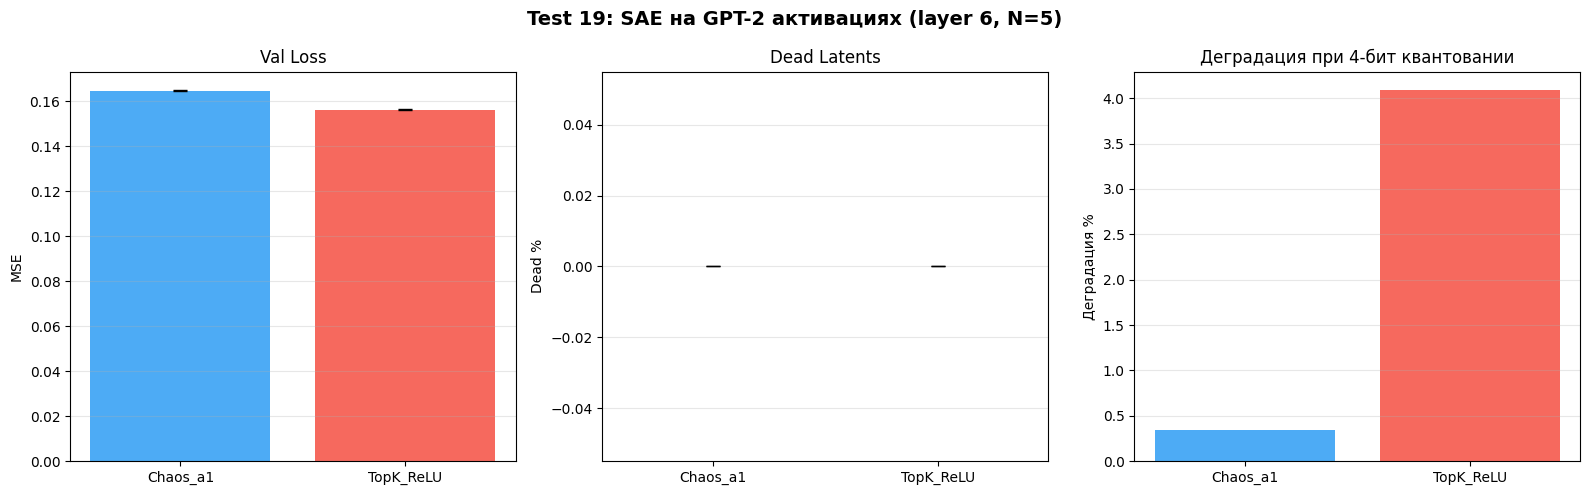

In [17]:
# === Визуализация ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

method_names = list(methods.keys())
colors = ['#2196F3', '#F44336']

# Val Loss
for i, m in enumerate(method_names):
    vals = [r['val_loss'] for r in results[m]]
    axes[0].bar(i, np.mean(vals), yerr=np.std(vals), capsize=5,
                color=colors[i], alpha=0.8, label=m)
axes[0].set_xticks(range(len(method_names)))
axes[0].set_xticklabels(method_names)
axes[0].set_ylabel('MSE')
axes[0].set_title('Val Loss')
axes[0].grid(True, alpha=0.3, axis='y')

# Dead neurons
for i, m in enumerate(method_names):
    vals = [r['dead_pct'] for r in results[m]]
    axes[1].bar(i, np.mean(vals), yerr=np.std(vals), capsize=5,
                color=colors[i], alpha=0.8, label=m)
axes[1].set_xticks(range(len(method_names)))
axes[1].set_xticklabels(method_names)
axes[1].set_ylabel('Dead %')
axes[1].set_title('Dead Latents')
axes[1].grid(True, alpha=0.3, axis='y')

# Quantization degradation
for i, m in enumerate(method_names):
    bl = np.mean([r['val_loss'] for r in results[m]])
    ql = np.mean([r['quant4_loss'] for r in results[m]])
    degrad = (ql - bl) / bl * 100
    axes[2].bar(i, degrad, color=colors[i], alpha=0.8, label=m)
axes[2].set_xticks(range(len(method_names)))
axes[2].set_xticklabels(method_names)
axes[2].set_ylabel('Деградация %')
axes[2].set_title('Деградация при 4-бит квантовании')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Test 19: SAE на GPT-2 активациях (layer {TARGET_LAYER}, N={NUM_RUNS})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# === Анализ dead latents по прогонам ===
print("\nDead latents по прогонам:")
print(f"{'Run':<6} {'Chaos Dead':>12} {'ReLU Dead':>12}")
print('-' * 35)
for i in range(NUM_RUNS):
    cd = results['Chaos_a1'][i]['dead_neurons']
    rd = results['TopK_ReLU'][i]['dead_neurons']
    print(f"{i+1:<6} {cd:>8}/{LATENT_DIM} {rd:>8}/{LATENT_DIM}")


Dead latents по прогонам:
Run      Chaos Dead    ReLU Dead
-----------------------------------
1             0/3072        0/3072
2             0/3072        0/3072
3             0/3072        0/3072
4             0/3072        0/3072
5             0/3072        0/3072


In [19]:
# === Сохранение ===
save_data = {
    'experiment': 'llm_activations_sae',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'llm_model': 'gpt2',
        'target_layer': TARGET_LAYER,
        'activation_dim': ACTIVATION_DIM,
        'num_activations': len(activations_norm),
        'latent_dim': LATENT_DIM,
        'k_active': K_ACTIVE,
        'overcomplete_ratio': LATENT_DIM / ACTIVATION_DIM,
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
    },
    'results': results,
}

json_path = f'../jsons/llm_activations_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/llm_activations_20260408_155532.json
